In [2]:
import pyxdf

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

In [3]:
file_path=r"C:\Users\abolhassni\Desktop\TU Darmstadt\Term3\ANSYMB\LSL\imu_motion_capture_analysis\data\raw\TEST 27 MAI\flexionandextension.xdf"

streams, header=pyxdf.load_xdf(file_path)


In [4]:
columns = [
    "qw", "qx", "qy", "qz",
    "ax", "ay", "az",
    "gx", "gy", "gz",
    "mx", "my", "mz",
    "packet_counter",
    "sample_time_fine"
]

sensor_dfs = {}

for stream in streams:
    sensor_name = stream["info"]["name"][0]
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    df = pd.DataFrame(data, columns=columns)
    df["time_stamp"] = time
    df["time_insert"] = time - time[0]
    
    sensor_dfs[sensor_name] = df

In [5]:
sensor_map = {
    "Xsens_MTw2_00B4D0C5": "Pelv",
    "Xsens_MTw2_00B4D0BE": "lLeg_L",
    "Xsens_MTw2_00B4D0C8": "uLeg_L",
    "Xsens_MTw2_00B4D0D0": "Foot_L"
}

sensor_dfs_mapped = {}

for sensor_id, body_name in sensor_map.items():
    if sensor_id in sensor_dfs:
        sensor_dfs_mapped[body_name] = sensor_dfs[sensor_id]

In [6]:
sensor_dfs_mapped.keys()

dict_keys(['Pelv', 'lLeg_L', 'uLeg_L', 'Foot_L'])

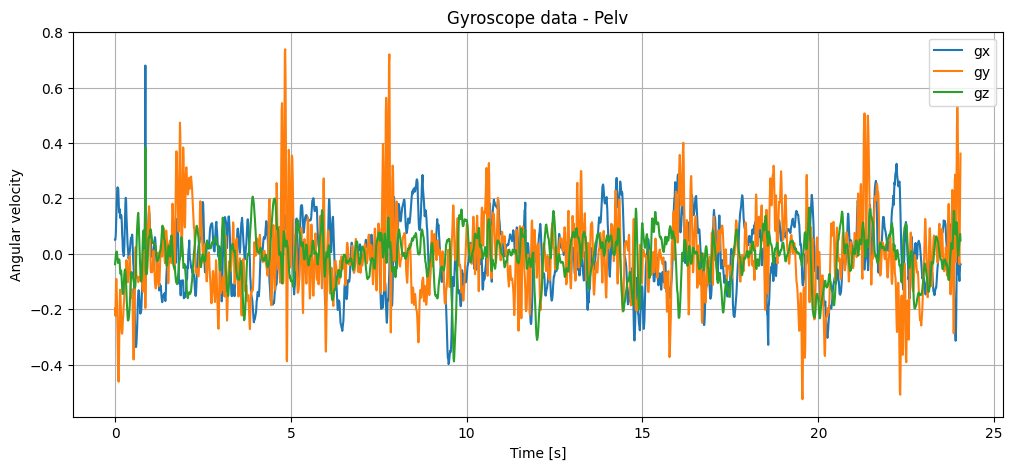

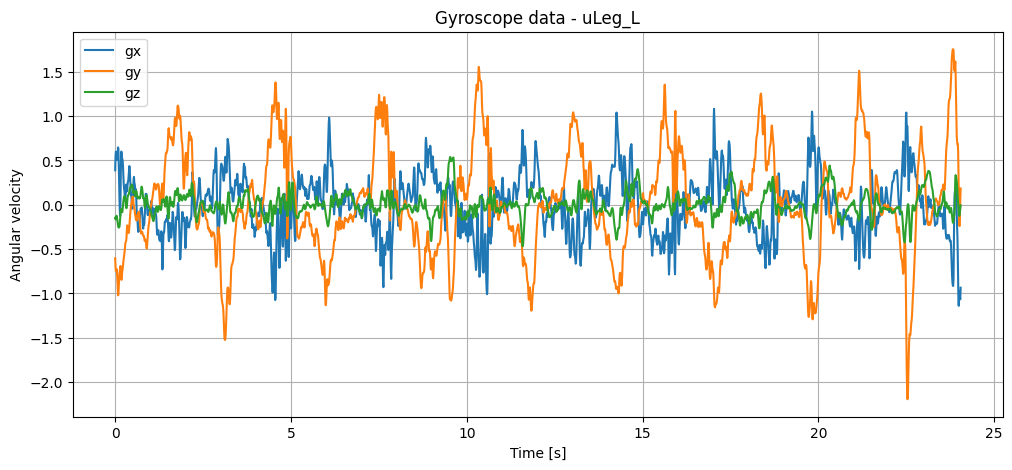

In [7]:
for sensor_name in ["Pelv", "uLeg_L"]:
    df = sensor_dfs_mapped[sensor_name]
    
    t = df["time_insert"]
    
    plt.figure(figsize=(12, 5))
    plt.plot(t, df["gx"], label="gx")
    plt.plot(t, df["gy"], label="gy")
    plt.plot(t, df["gz"], label="gz")
    
    plt.xlabel("Time [s]")
    plt.ylabel("Angular velocity")
    plt.title(f"Gyroscope data - {sensor_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
for sensor_name in ["Pelv", "uLeg_L"]:
    df = sensor_dfs_mapped[sensor_name]
    
  
    df_move = df[
        (df["time_insert"] >= 0) &
        (df["time_insert"] <= 24)
    ]
    
    gyro_rms = np.sqrt((df_move[["gx", "gy", "gz"]]**2).mean())
    
    print(sensor_name)
    print(gyro_rms)
    print("Dominant axis:", gyro_rms.idxmax())
    print("--------------------")

Pelv
gx    0.120361
gy    0.139770
gz    0.083274
dtype: float32
Dominant axis: gy
--------------------
uLeg_L
gx    0.324370
gy    0.581332
gz    0.133888
dtype: float32
Dominant axis: gy
--------------------


In [9]:
def dominant_rotation_axis(df, t_start, t_end):
    df_move = df[
        (df["time_insert"] >= t_start) &
        (df["time_insert"] <= t_end)
    ]
    
    W = df_move[["gx", "gy", "gz"]].to_numpy()
    W = W - W.mean(axis=0)
    
    U, S, Vt = np.linalg.svd(W, full_matrices=False)
    
    axis = Vt[0]
    axis = axis / np.linalg.norm(axis)
    
    explained_variance = S[0]**2 / np.sum(S**2)
    
    return axis, explained_variance

In [10]:
for sensor_name in ["Pelv", "uLeg_L"]:
    axis, explained = dominant_rotation_axis(
        sensor_dfs_mapped[sensor_name],
        0,
        24
    )
    
    print(sensor_name)
    print("Dominant rotation axis:", axis)
    print("Explained variance:", round(explained, 3))
    print("--------------------")

Pelv
Dominant rotation axis: [-0.08173106 -0.99656093 -0.01365335]
Explained variance: 0.478
--------------------
uLeg_L
Dominant rotation axis: [-0.42945015  0.9025382   0.03158319]
Explained variance: 0.881
--------------------


In [11]:
sensor_axes = {
    "+X": np.array([1, 0, 0]),
    "-X": np.array([-1, 0, 0]),
    "+Y": np.array([0, 1, 0]),
    "-Y": np.array([0, -1, 0]),
    "+Z": np.array([0, 0, 1]),
    "-Z": np.array([0, 0, -1])
}

def nearest_axis(vector):
    vector = vector / np.linalg.norm(vector)
    
    best_name = None
    best_angle = 999
    
    for axis_name, axis_vector in sensor_axes.items():
        angle = np.degrees(
            np.arccos(
                np.clip(np.dot(vector, axis_vector), -1, 1)
            )
        )
        
        if angle < best_angle:
            best_angle = angle
            best_name = axis_name
    
    return best_name, best_angle

In [12]:
for sensor_name in ["Pelv", "uLeg_L"]:
    axis, explained = dominant_rotation_axis(
        sensor_dfs_mapped[sensor_name],
        0,
        24
    )
    
    axis_name, angle = nearest_axis(axis)
    
    print(sensor_name)
    print("Nearest sensor axis:", axis_name)
    print("Angle:", round(angle, 2), "deg")
    print("Explained variance:", round(explained, 3))
    print("--------------------")

Pelv
Nearest sensor axis: -Y
Angle: 4.75 deg
Explained variance: 0.478
--------------------
uLeg_L
Nearest sensor axis: +Y
Angle: 25.51 deg
Explained variance: 0.881
--------------------


In [13]:
for sensor_name in ["Pelv", "uLeg_L"]:
    df = sensor_dfs_mapped[sensor_name]

    df_move = df[
        (df["time_insert"] >= 0) &
        (df["time_insert"] <= 24)
    ]

    gyro_rms = np.sqrt((df_move[["gx", "gy", "gz"]]**2).mean())

    print(sensor_name)
    print(gyro_rms)
    print("Dominant axis:", gyro_rms.idxmax())
    print("--------------------")

Pelv
gx    0.120361
gy    0.139770
gz    0.083274
dtype: float32
Dominant axis: gy
--------------------
uLeg_L
gx    0.324370
gy    0.581332
gz    0.133888
dtype: float32
Dominant axis: gy
--------------------
